## Credit Card Fraud Detection

In this project you will predict fraudulent credit card transactions with the help of Machine learning models. Please import the following libraries to get started.

In [64]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#import all the required library for machine learning 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


import warnings
warnings.filterwarnings("ignore")

## Exploratory data analysis

In [3]:
df = pd.read_csv("D://Upgrad - Executive PG in ML & AI//Capstone//archive//creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
#observe the different feature type present in the data
# check the dataset shape
df.shape


(284807, 31)

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
print(df.dtypes)
print(df.info())

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      

### Handling Missing Values

In [18]:
# check the missing value in the dataset
df.isnull().sum().sum()

0

### Here we will observe the distribution of our classes

In [12]:
classes=df['Class'].value_counts()
classes

0    284315
1       492
Name: Class, dtype: int64

In [13]:
normal_share=classes[0]/df['Class'].count()*100
normal_share

99.82725143693798

In [14]:
fraud_share=classes[1]/df['Class'].count()*100
fraud_share

0.1727485630620034

In [15]:
df['Class'].count()

284807

### Interpretation:
There exist a problem of Class Imbalance

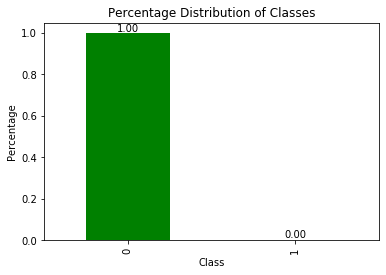

In [20]:
# Create a bar plot for the number and percentage of fraudulent vs non-fraudulent transcations

# ax = df['Class'].value_counts(normalize = True).plot.bar(color = ['g', 'r'])
# ax.bar_label(ax.containers[0], label_type='edge')
# plt.title('Percentage Distribution of Classes')
# plt.xlabel('Class')
# plt.ylabel('Percentage')
# plt.show()
ax = df['Class'].value_counts(normalize=True).plot.bar(color=['g', 'r'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Percentage Distribution of Classes')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

Text(0, 0.5, 'Frequncy')

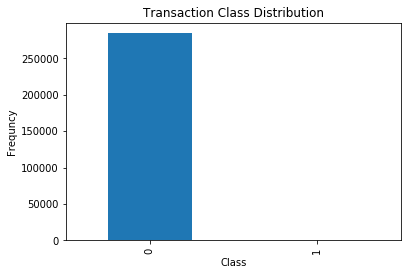

In [22]:
ax = df.Class.value_counts().plot(kind='bar')

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequncy")

### 0-->Ligit(Normal)transaction

### 1-->Fraud transaction

#### As can seen, this is highly unbalanced the data. The noraml transaction is 284315 and only 492 is fraud transaction.

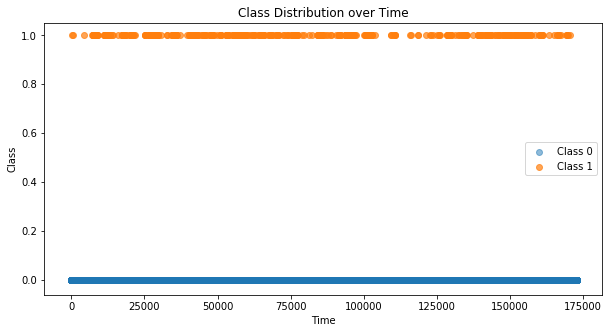

In [24]:
# Create a scatter plot to observe the distribution of classes with Amount
plt.figure(figsize=(10,5))

df0 = df[df['Class'] == 0]
df1 = df[df['Class'] == 1]

plt.scatter(df0['Time'], df0['Class'], label='Class 0', alpha=0.5)
plt.scatter(df1['Time'], df1['Class'], label='Class 1', alpha=0.7)

plt.legend()
plt.title('Class Distribution over Time')
plt.xlabel('Time')
plt.ylabel('Class')

plt.show()

In [26]:
# seprating the data analysis
normal = df[df.Class == 0]
fraud = df[df.Class == 1]

In [27]:
print(normal.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [29]:
nt = len(normal)/len(df)*100
print(nt)

99.82725143693798


In [30]:
ft = len(fraud)/len(df)*100
print(ft)

0.1727485630620034


Only 0.17% fraudulent transaction out all the transactions. The data is highly Unbalanced. Lets first apply our models without balancing it and if we don’t get a good accuracy then we can find a way to balance this dataset. But first, let’s implement the model without it and will balance the data only if needed.

In [31]:
# seprating the data amount wise analysis
normal.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [32]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

As we can clearly notice from this, the average Money transaction for the fraudulent ones is more. This makes this problem crucial to deal with.

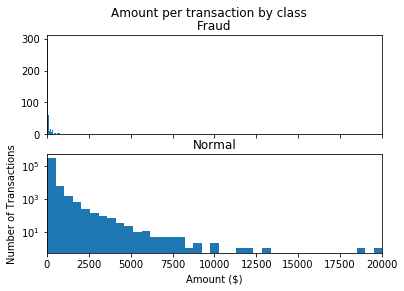

In [33]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.Amount, bins = bins)
ax1.set_title('Fraud')
ax2.hist(normal.Amount, bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

### Handle the Unbalance data

The data is highly unbalanced. The noraml transaction is 284315 and only 492 is fraud transaction.

Using the under sampling method we balance the data.

In [35]:
legit = normal.sample(n=492)

In [36]:
# using the under sampling method merage the ligit and fraud dataframe
new_df  = pd.concat([legit,fraud], axis = 0)

In [37]:
new_df["Class"].value_counts()

0    492
1    492
Name: Class, dtype: int64

### Splitting the data into Features & Targets

In [38]:
x = new_df.drop(columns= "Class", axis = 1)
y = new_df.Class

### Splitting the data into train & test data

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state= 40)

In [40]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(787, 30) (197, 30) (787,) (197,)


##### Preserve X_test & y_test to evaluate on the test data once you build the model

In [41]:
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

492
393
99


### Plotting the distribution of a variable

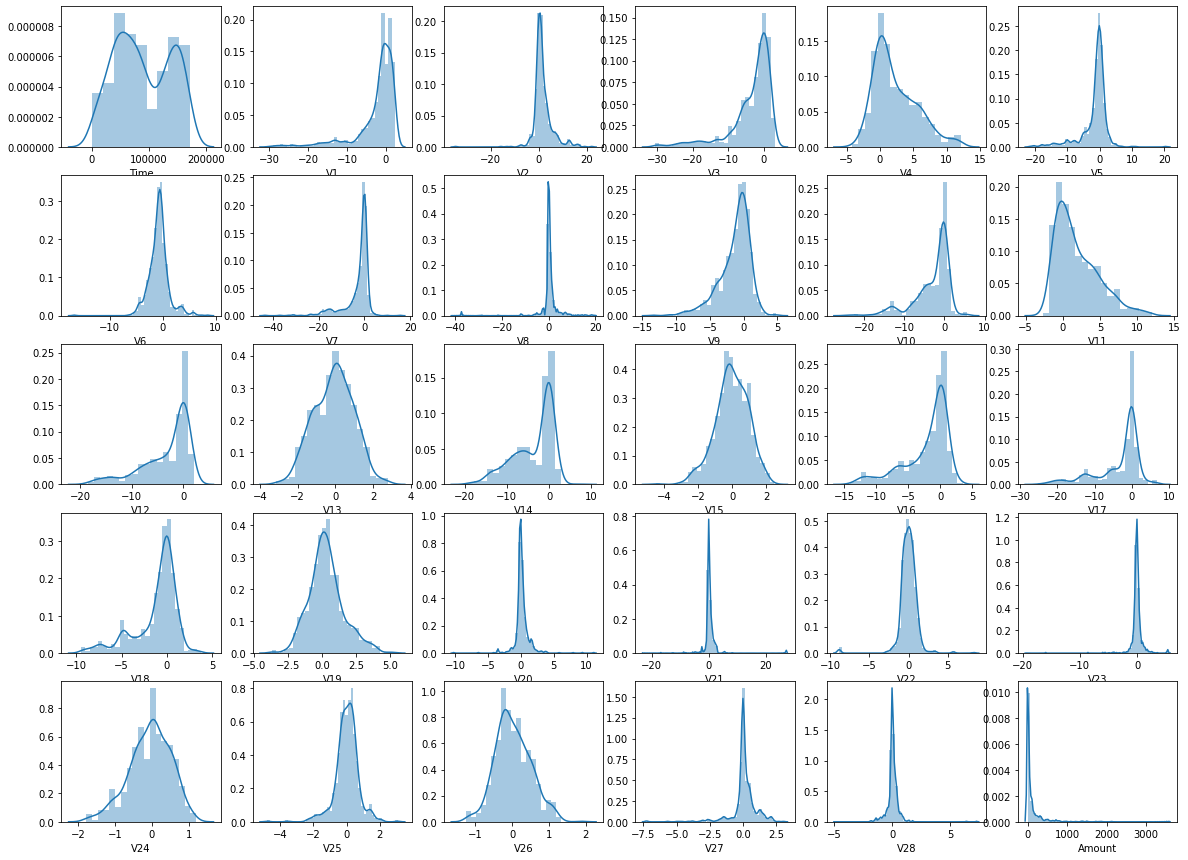

In [44]:
# plot the histogram of a variable from the dataset to see the skewness
var = x_train.columns

plt.figure(figsize=(20,15))
i=0
for col in var:
    i += 1
    plt.subplot(5,6, i)
    sns.distplot(x_train[col])

plt.show()

In [48]:
# Lets check the skewness of the features
var = x_train.columns
skew_list = []
for i in var:
    skew_list.append(x_train[i].skew())

tmp = pd.concat([pd.DataFrame(var, columns=["Features"]), pd.DataFrame(skew_list, columns=["Skewness"])], axis=1)
tmp.set_index("Features", inplace=True)
tmp.T

Features,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Skewness,0.096232,-2.476073,0.131248,-2.054552,0.847222,-1.831127,-0.115905,-2.517671,-4.224566,-1.267634,...,1.085996,4.926814,-2.357948,-6.508551,-0.446893,-0.781677,0.261866,-2.319304,3.347741,5.927129


In [49]:
# Filtering the features which has skewness less than -1 and greater than +1
skewed = tmp.loc[(tmp["Skewness"] > 1) | (tmp["Skewness"] <-1 )].index
print(skewed)

Index(['V1', 'V3', 'V5', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V16', 'V17',
       'V18', 'V20', 'V21', 'V22', 'V23', 'V27', 'V28', 'Amount'],
      dtype='object', name='Features')


### There is skewness present in the distribution use:
- <b>Power Transformer</b> package present in the <b>preprocessing library provided by sklearn</b> to make distribution more gaussian

In [50]:
from sklearn.preprocessing import PowerTransformer

In [51]:
# preprocessing.PowerTransformer(copy=False) to fit & transform the train & test data
pt = PowerTransformer(copy=False)

# Fitting the power transformer in train data
x_train[skewed] = pt.fit_transform(x_train[skewed])


# Transforming the test data
x_test[skewed] = pt.transform(x_test[skewed])

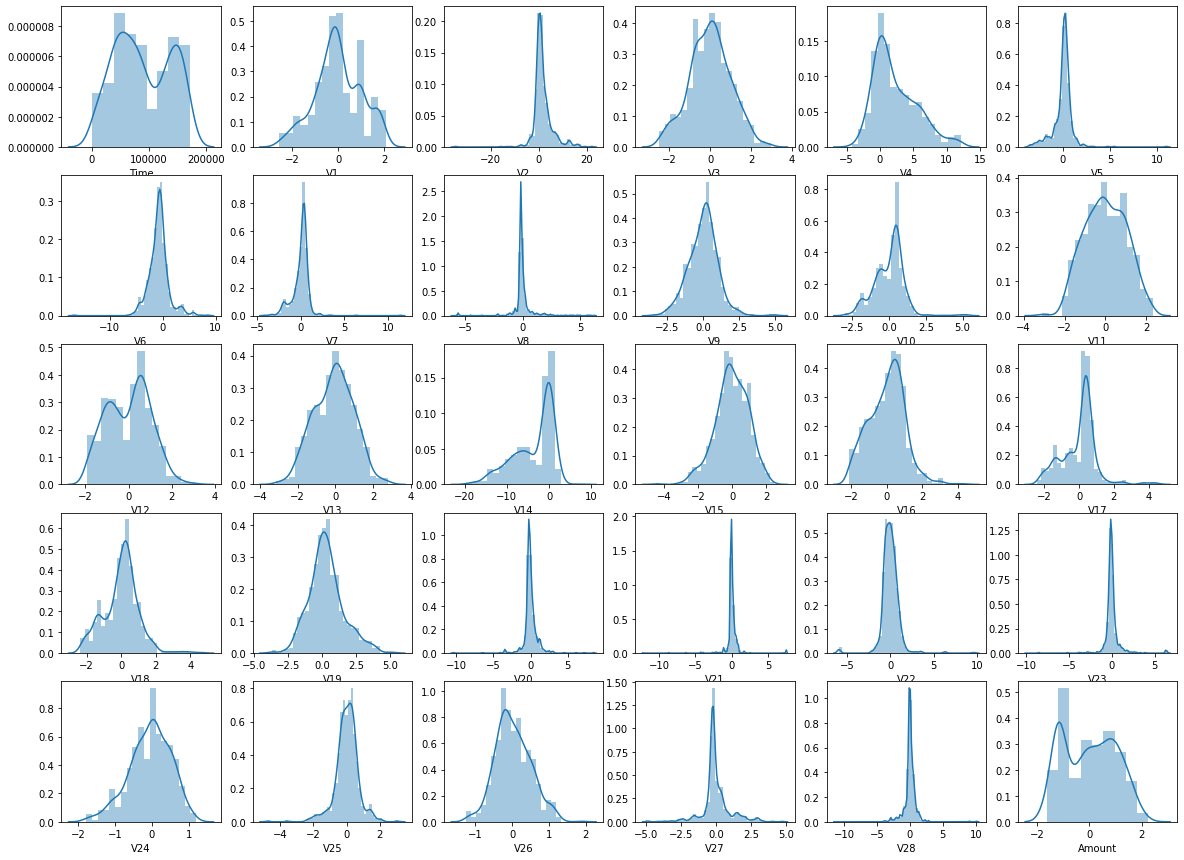

In [52]:
# plot the histogram of a variable from the dataset again to see the result 
var = x_train.columns

plt.figure(figsize=(20,15))
i=0
for col in var:
    i += 1
    plt.subplot(5,6, i)
    sns.distplot(x_train[col])

plt.show()

## Model Building
- Build different models on the imbalanced dataset and see the result

### Metric selection on imbalance data


For the purpose of evaluating the model, we will employ the ROC-AUC score as the assessment metric. Since there are very few fraud incidents overall and the data is very skewed, accuracy is not the appropriate statistic to assess the model.

## 1. Logistic Regression

In [56]:
# Logistic Regression parameters for K-fold cross vaidation
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}
folds = KFold(n_splits=5, shuffle=True, random_state=4)


#perform cross validation
model_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        n_jobs=1,
                        verbose = 1,
                        return_train_score=True) 
#perform hyperparameter tuning
model_cv.fit(x_train, y_train)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', model_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', model_cv.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best ROC AUC score:  0.9745403298887638
Best hyperparameters:  {'C': 10}


In [57]:
# cross validation results
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.102140,0.126130,0.012703,0.014471,0.01,{'C': 0.01},0.955823,0.955032,0.987092,0.967574,...,0.964291,0.012312,6,0.962575,0.977256,0.956538,0.959333,0.963070,0.963754,0.007152
1,0.094600,0.051359,0.012048,0.005439,0.1,{'C': 0.1},0.956466,0.962825,0.988072,0.990927,...,0.974227,0.013550,2,0.965891,0.982517,0.959744,0.985576,0.981334,0.975012,0.010239
2,0.130110,0.040065,0.007267,0.001057,1,{'C': 1},0.956305,0.962987,0.981536,0.987399,...,0.970914,0.011677,5,0.966791,0.990459,0.981127,0.985919,0.989236,0.982706,0.008589
3,0.084346,0.048171,0.008576,0.002149,10,{'C': 10},0.956466,0.964448,0.988562,0.989079,...,0.974540,0.012936,1,0.966913,0.983842,0.960691,0.984364,0.982997,0.975761,0.009971
4,0.068186,0.022000,0.006559,0.000820,100,{'C': 100},0.956627,0.964448,0.981863,0.988071,...,0.972511,0.011383,4,0.966953,0.983832,0.981248,0.985909,0.987714,0.981131,0.007409
5,0.056143,0.011499,0.007931,0.002001,1000,{'C': 1000},0.956627,0.963149,0.981863,0.989079,...,0.972973,0.011862,3,0.966953,0.990166,0.981268,0.984283,0.983017,0.981137,0.007696


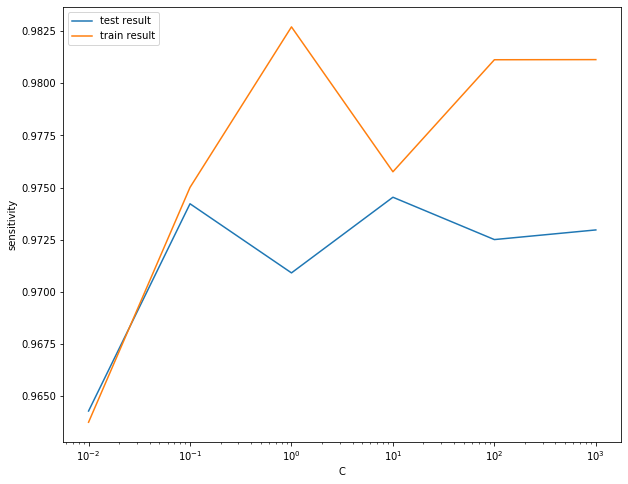

In [58]:
# plot of C versus train and validation scores
plt.figure(figsize=(10, 8))
plt.plot(cv_results['param_C'], cv_results['mean_test_score'])
plt.plot(cv_results['param_C'], cv_results['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Logistic Regression with optimal C

In [59]:
# Instantiating the model with best C
log_reg_imb_model = LogisticRegression(C=10)

# Fitting the model on train dataset
log_reg_imb_model.fit(x_train, y_train)

LogisticRegression(C=10)

### Prediction and model evalution on the train set

In [65]:
# Creating function to display ROC-AUC score, f1 score and classification report
def display_scores(y_test, y_pred):
    '''
    Display ROC-AUC score, f1 score and classification report of a model.
    '''
    print(f"F1 Score: {round(f1_score(y_test, y_pred)*100,2)}%") 
    print(f"Classification Report: \n {classification_report(y_test, y_pred)}")

In [66]:
# Predictions on the train set
y_train_pred = log_reg_imb_model.predict(x_train)

In [67]:
display_scores(y_train, y_train_pred)

F1 Score: 94.74%
Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       394
           1       0.98      0.92      0.95       393

    accuracy                           0.95       787
   macro avg       0.95      0.95      0.95       787
weighted avg       0.95      0.95      0.95       787



In [68]:
# ROC Curve function
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [70]:
# Predicted probability
y_train_pred_proba = log_reg_imb_model.predict_proba(x_train)[:,1]

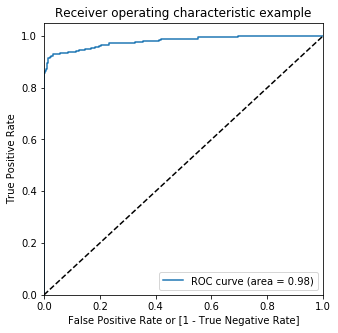

In [71]:
# Plot the ROC curve
draw_roc(y_train, y_train_pred_proba)

### Evaluating the model on the test set

In [73]:
# Making prediction on the test set
y_test_pred = log_reg_imb_model.predict(x_test)
display_scores(y_test, y_test_pred)

F1 Score: 92.47%
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.99      0.93        98
           1       0.99      0.87      0.92        99

    accuracy                           0.93       197
   macro avg       0.94      0.93      0.93       197
weighted avg       0.94      0.93      0.93       197



In [75]:
# Predicted probability
y_test_pred_proba = log_reg_imb_model.predict_proba(x_test)[:,1]

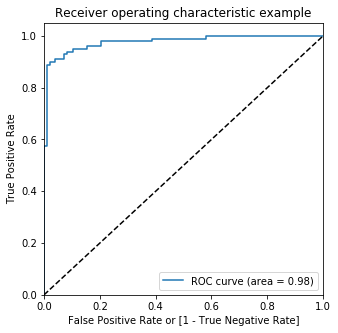

In [76]:
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

We can see very good ROC on the test data set 0.98.

Model Summary:

#### Train set-

ROC : 98%

F1 Score: 94.74%


#### Test set-

ROC : 98%

F1 score: 92.47%

## 2. Decision Tree

In [79]:
# Create the parameter grid 
param_grid = {
    'max_depth': range(5, 15, 5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
}


# Instantiate the grid search model
dtree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator = dtree, 
                           param_grid = param_grid, 
                           scoring= 'roc_auc',
                           cv = 3, 
                           n_jobs=1,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(x_train,y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=1,
             param_grid={'max_depth': range(5, 15, 5),
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50)},
             scoring='roc_auc', verbose=1)

In [80]:
# cv results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.057500,0.065000,0.012568,9.308665e-03,5,50,50,"{'max_depth': 5, 'min_samples_leaf': 50, 'min_...",0.971027,0.953761,0.943651,0.956147,0.011303,3
1,0.010637,0.001696,0.005321,4.713705e-04,5,50,100,"{'max_depth': 5, 'min_samples_leaf': 50, 'min_...",0.969148,0.954723,0.947439,0.957103,0.009021,2
2,0.009023,0.000066,0.005063,7.227617e-04,5,100,50,"{'max_depth': 5, 'min_samples_leaf': 100, 'min...",0.964030,0.948488,0.941495,0.951338,0.009418,6
3,0.009307,0.000471,0.004988,4.899036e-07,5,100,100,"{'max_depth': 5, 'min_samples_leaf': 100, 'min...",0.964030,0.947585,0.941845,0.951153,0.009402,7
4,0.010636,0.000470,0.005320,1.242413e-03,10,50,50,"{'max_depth': 10, 'min_samples_leaf': 50, 'min...",0.970709,0.957112,0.943651,0.957157,0.011046,1
5,0.020639,0.002481,0.010279,1.733222e-03,10,50,100,"{'max_depth': 10, 'min_samples_leaf': 50, 'min...",0.969437,0.940097,0.939281,0.949605,0.014027,8
6,0.014294,0.003390,0.008533,2.522396e-03,10,100,50,"{'max_depth': 10, 'min_samples_leaf': 100, 'mi...",0.964087,0.949770,0.940971,0.951609,0.009527,5
7,0.009561,0.000245,0.005515,1.035706e-03,10,100,100,"{'max_depth': 10, 'min_samples_leaf': 100, 'mi...",0.964030,0.949770,0.941379,0.951726,0.009350,4


In [81]:
# Printing the optimal score and hyperparameters
print("Best roc auc score : ", grid_search.best_score_)
print(grid_search.best_estimator_)

Best roc auc score :  0.95715745238646
DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, min_samples_split=50)


### Decision Tree with optimal hyperparameters

In [82]:
# Model with optimal hyperparameters
dt_imb_model = DecisionTreeClassifier(criterion = "gini", 
                                  random_state = 100,
                                  max_depth=10, 
                                  min_samples_leaf=100,
                                  min_samples_split=100)

dt_imb_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=100,
                       min_samples_split=100, random_state=100)

In [85]:
# Prediction on the train set
y_train_pred = dt_imb_model.predict(x_train)
display_scores(y_train, y_train_pred)

F1 Score: 92.16%
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       394
           1       0.98      0.87      0.92       393

    accuracy                           0.93       787
   macro avg       0.93      0.93      0.93       787
weighted avg       0.93      0.93      0.93       787



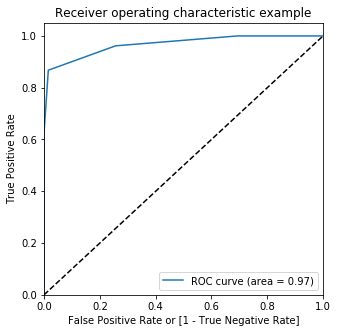

In [86]:
# Predicted probability
y_train_pred_proba = dt_imb_model.predict_proba(x_train)[:,1]

# Plot the ROC curve
draw_roc(y_train, y_train_pred_proba)

In [87]:
# Evaluating the model on the test set
y_test_pred = dt_imb_model.predict(x_test)
display_scores(y_test, y_test_pred)

F1 Score: 87.78%
Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.98      0.90        98
           1       0.98      0.80      0.88        99

    accuracy                           0.89       197
   macro avg       0.90      0.89      0.89       197
weighted avg       0.90      0.89      0.89       197



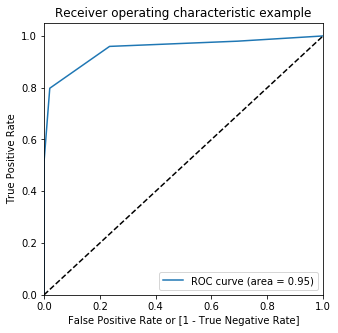

In [88]:
# Predicted probability
y_test_pred_proba = dt_imb_model.predict_proba(x_test)[:,1]

# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

Model Summary

#### Train set

ROC Score: 97% 

F1 score : 92.16%


#### Test set

ROC Score: 95% 

F1 score : 87.78%

## Model building with balancing Classes

##### Perform class balancing with :
- Random Oversampling
- SMOTE


## Random Oversampling


In [90]:
# Logistic Regression
from imblearn.over_sampling import RandomOverSampler

# define oversampling strategy
oversample = RandomOverSampler(sampling_strategy='minority')
# fit and apply the transform
X_over, y_over = oversample.fit_resample(x_train, y_train)

In [91]:
from collections import Counter
# Befor sampling class distribution
print('Before sampling class distribution:-',Counter(y_train))
# new class distribution 
print('New class distribution:-',Counter(y_over))

Before sampling class distribution:- Counter({0: 394, 1: 393})
New class distribution:- Counter({1: 394, 0: 394})


In [92]:
# Creating KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=4)

# Specify params
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}

# Specifing score as roc-auc
model_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True) 

# Fit the model
model_cv.fit(X_over, y_over)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', model_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', model_cv.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best ROC AUC score:  0.9734168147352712
Best hyperparameters:  {'C': 0.1}


In [93]:
# cross validation results
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.155707,0.158496,0.026326,0.036838,0.01,{'C': 0.01},0.971919,0.985739,0.975449,0.961526,...,0.969892,0.010799,6,0.974984,0.971630,0.973039,0.975485,0.963672,0.971762,0.004274
1,0.068417,0.010065,0.008976,0.001892,0.1,{'C': 0.1},0.977214,0.987342,0.973684,0.957546,...,0.973417,0.009641,1,0.981888,0.978634,0.962950,0.965687,0.980987,0.974029,0.008047
2,0.098135,0.048083,0.008378,0.003710,1,{'C': 1},0.965340,0.981734,0.973524,0.958375,...,0.970413,0.007946,5,0.964572,0.985780,0.963897,0.966461,0.982022,0.972546,0.009384
3,0.074003,0.032381,0.007379,0.001954,10,{'C': 10},0.978819,0.981573,0.973524,0.958541,...,0.973240,0.007962,2,0.983309,0.985578,0.963988,0.966582,0.987529,0.977397,0.010013
4,0.081982,0.027126,0.008976,0.001410,100,{'C': 100},0.978819,0.981413,0.973524,0.958541,...,0.973176,0.007927,4,0.983349,0.985488,0.964028,0.966572,0.982102,0.976308,0.009089
5,0.076793,0.026180,0.008181,0.001599,1000,{'C': 1000},0.978819,0.981413,0.973524,0.958541,...,0.973208,0.007929,3,0.983349,0.985477,0.964038,0.966582,0.987489,0.977387,0.009980


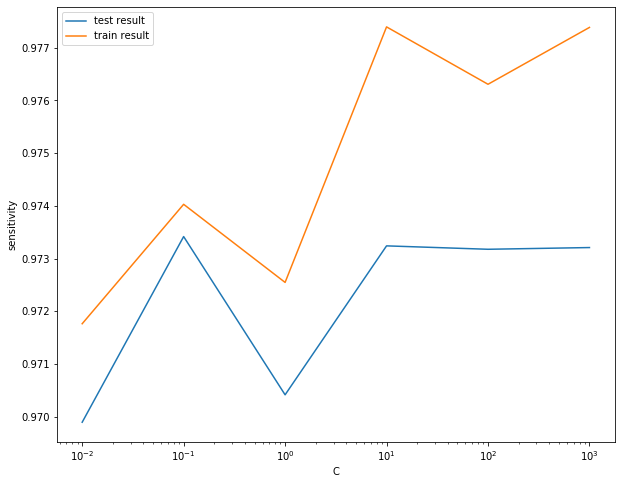

In [94]:
# plot of C versus train and validation scores
plt.figure(figsize=(10, 8))
plt.plot(cv_results['param_C'], cv_results['mean_test_score'])
plt.plot(cv_results['param_C'], cv_results['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Logistic Regression with hyperparameter tuning

In [95]:
model_cv.best_params_

{'C': 0.1}

In [96]:
# Instantiating the model
logreg_over = LogisticRegression(C=1000)

# Fitting the model with train data
logreg_over_model = logreg_over.fit(X_over, y_over)

#### Evaluating the model on train data

In [98]:
# Predictions on the train set
y_train_pred = logreg_over_model.predict(X_over)
# Printing scores
display_scores(y_over, y_train_pred)

F1 Score: 94.46%
Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       394
           1       0.98      0.91      0.94       394

    accuracy                           0.95       788
   macro avg       0.95      0.95      0.95       788
weighted avg       0.95      0.95      0.95       788



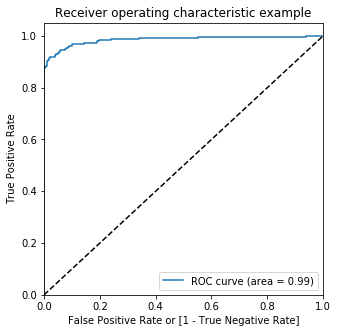

In [99]:
# Predicted probability
y_train_pred_proba = logreg_over_model.predict_proba(X_over)[:,1]
# Plot the ROC curve
draw_roc(y_over, y_train_pred_proba)

#### Evaluating on test data

In [101]:
# Evaluating on test data
y_test_pred = logreg_over_model.predict(x_test)

# Printing the scores
display_scores(y_test, y_test_pred)

F1 Score: 89.13%
Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90        98
           1       0.96      0.83      0.89        99

    accuracy                           0.90       197
   macro avg       0.91      0.90      0.90       197
weighted avg       0.91      0.90      0.90       197



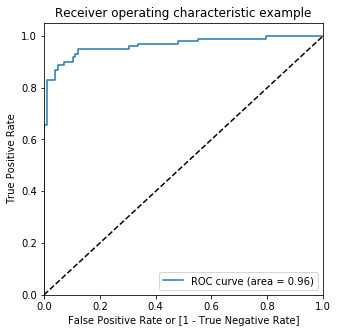

In [103]:
# Predicted probability
y_test_pred_proba = logreg_over_model.predict_proba(x_test)[:,1]

# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

### 2. Decision Tree with Random Oversampling

In [105]:
# Create the parameter grid 
param_grid = {
    'max_depth': range(5, 15, 5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
}


# Instantiate the grid search model
dtree = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator = dtree, 
                           param_grid = param_grid, 
                           scoring= 'roc_auc',
                           cv = 3, 
                           n_jobs=1,
                          # n_jobs=-1,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_over,y_over)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=1,
             param_grid={'max_depth': range(5, 15, 5),
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50)},
             scoring='roc_auc', verbose=1)

In [106]:
# Printing the optimal roc score and hyperparameters
print("Best roc auc score : ", grid_search.best_score_)
print(grid_search.best_estimator_)

Best roc auc score :  0.9606058545951326
DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=50)


#### Decision Tree with optimal hyperparameters

In [108]:
# Model with optimal hyperparameters
dt_over_model = DecisionTreeClassifier(criterion = "gini", 
                                  random_state = 100,
                                  max_depth=10, 
                                  min_samples_leaf=100,
                                  min_samples_split=100)

dt_over_model.fit(X_over, y_over)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=100,
                       min_samples_split=100, random_state=100)

### Model evatuation on train data

In [109]:
# Predictions on the train set
y_train_pred = dt_over_model.predict(X_over)
display_scores(y_over, y_train_pred)

F1 Score: 92.18%
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       394
           1       0.98      0.87      0.92       394

    accuracy                           0.93       788
   macro avg       0.93      0.93      0.93       788
weighted avg       0.93      0.93      0.93       788



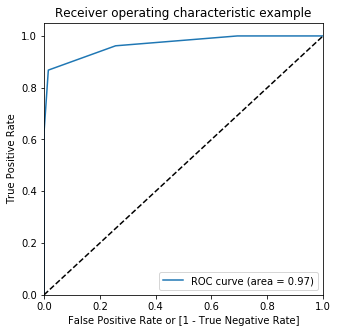

In [111]:
# Predicted probability
y_train_pred_proba = dt_over_model.predict_proba(X_over)[:,1]
# Plot the ROC curve
draw_roc(y_over, y_train_pred_proba)

### Predictions on the test set

In [113]:
# Evaluating model on the test data
y_test_pred = dt_over_model.predict(x_test)
display_scores(y_test, y_test_pred)

F1 Score: 87.78%
Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.98      0.90        98
           1       0.98      0.80      0.88        99

    accuracy                           0.89       197
   macro avg       0.90      0.89      0.89       197
weighted avg       0.90      0.89      0.89       197



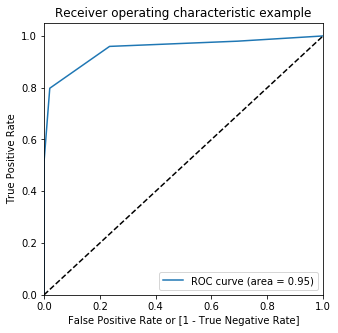

In [114]:
# Predicted probability
y_test_pred_proba = dt_over_model.predict_proba(x_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba)

## SMOTE (Synthetic Minority Oversampling Technique)

### Print the class distribution after applying SMOTE 

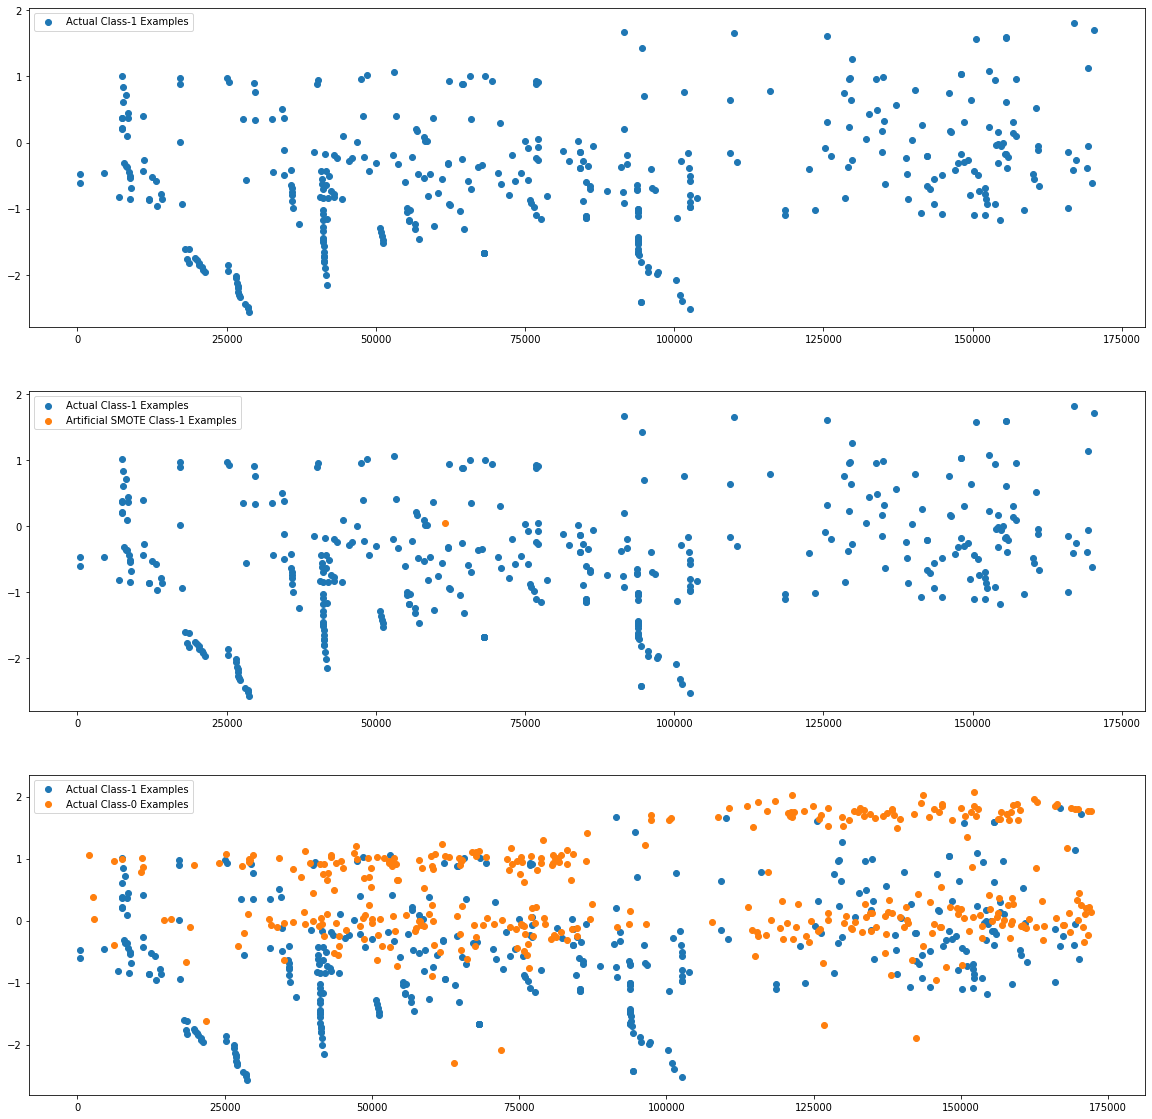

In [117]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=0)
X_train_smote, y_train_smote = sm.fit_resample(x_train, y_train)
# Artificial minority samples and corresponding minority labels from SMOTE are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from SMOTE, we do
X_train_smote_1 = X_train_smote[x_train.shape[0]:]

X_train_1 = x_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = x_train.to_numpy()[np.where(y_train==0.0)]


plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_smote_1.iloc[:X_train_1.shape[0], 0], X_train_smote_1.iloc[:X_train_1.shape[0], 1],
            label='Artificial SMOTE Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()

In [ ]:
#perform cross validation & then balance classes on X_train_cv & y_train_cv using SMOTE

#perform hyperparameter tuning

#print the evaluation result by choosing a evaluation metric

#print the optimum value of hyperparameters


##### Build models on other algorithms to see the better performing on SMOTE

### Print the class distribution after applying ADASYN

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

ada = over_sampling.ADASYN(random_state=0)
X_train_adasyn, y_train_adasyn = ada.fit_resample(X_train, y_train)
# Artificial minority samples and corresponding minority labels from ADASYN are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from ADASYN, we do
X_train_adasyn_1 = X_train_adasyn[X_train.shape[0]:]

X_train_1 = X_train.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train.to_numpy()[np.where(y_train==0.0)]



import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_adasyn_1[:X_train_1.shape[0], 0], X_train_adasyn_1[:X_train_1.shape[0], 1],
            label='Artificial ADASYN Class-1 Examples')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()

## Logistic Regression on balanced data with SMOTE

In [119]:
# Creating KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=4)

# Specify params
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}

# Specifing score as roc-auc
model_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'roc_auc', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True) 

# Fit the model
model_cv.fit(X_train_smote, y_train_smote)
#print the evaluation result by choosing a evaluation metric
print('Best ROC AUC score: ', model_cv.best_score_)
#print the optimum value of hyperparameters
print('Best hyperparameters: ', model_cv.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best ROC AUC score:  0.9744565244707635
Best hyperparameters:  {'C': 1}


In [120]:
# cross validation results
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.086769,0.113189,0.012367,0.014857,0.01,{'C': 0.01},0.961650,0.985739,0.975449,0.953068,...,0.966114,0.012598,6,0.961407,0.971630,0.972998,0.963695,0.963652,0.966677,0.004697
1,0.047273,0.009219,0.005585,0.001493,0.1,{'C': 0.1},0.977214,0.987342,0.976733,0.957546,...,0.974385,0.009661,2,0.981848,0.978634,0.977836,0.965667,0.988293,0.978456,0.007379
2,0.069214,0.066971,0.005784,0.000978,1,{'C': 1},0.978659,0.981734,0.980424,0.958375,...,0.974457,0.008564,1,0.983188,0.985780,0.986545,0.966451,0.988564,0.982106,0.008014
3,0.046672,0.017721,0.005985,0.001669,10,{'C': 10},0.978659,0.981573,0.976733,0.958706,...,0.973851,0.008006,5,0.983299,0.985578,0.979015,0.966532,0.987428,0.980371,0.007468
4,0.047474,0.014989,0.006184,0.000977,100,{'C': 100},0.978819,0.981413,0.976733,0.958706,...,0.973851,0.007995,3,0.983329,0.985488,0.979026,0.966532,0.982072,0.979289,0.006713
5,0.074600,0.036582,0.007812,0.001142,1000,{'C': 1000},0.978819,0.981413,0.976733,0.958706,...,0.973851,0.007995,3,0.983329,0.985477,0.979036,0.966532,0.982072,0.979289,0.006711


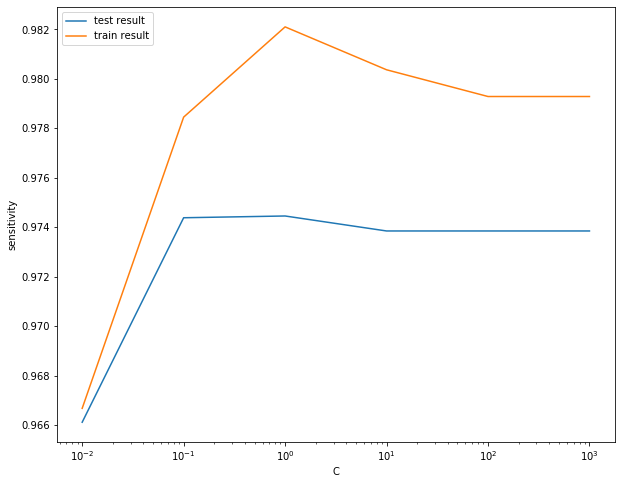

In [121]:
# plot of C versus train and validation scores

plt.figure(figsize=(10, 8))
plt.plot(cv_results['param_C'], cv_results['mean_test_score'])
plt.plot(cv_results['param_C'], cv_results['mean_train_score'])
plt.xlabel('C')
plt.ylabel('sensitivity')
plt.legend(['test result', 'train result'], loc='upper left')
plt.xscale('log')

### Logistic Regression with optimal C

In [122]:
# Printing best params
model_cv.best_params_

{'C': 1}

In [123]:
# Instantiating the model
logreg_smote_model = LogisticRegression(C=100)

# Fitting the model with balanced data
logreg_smote_model.fit(X_train_smote, y_train_smote)

LogisticRegression(C=100)

### Evaluating the model on train data

In [124]:
# Evaluating on train data
y_train_pred = logreg_smote_model.predict(X_train_smote)
display_scores(y_train_smote, y_train_pred)

F1 Score: 94.46%
Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       394
           1       0.98      0.91      0.94       394

    accuracy                           0.95       788
   macro avg       0.95      0.95      0.95       788
weighted avg       0.95      0.95      0.95       788



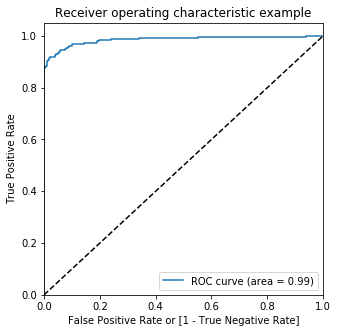

In [125]:
# Predicted probability
y_train_pred_proba_smote = logreg_smote_model.predict_proba(X_train_smote)[:,1]
# Plot the ROC curve
draw_roc(y_train_smote, y_train_pred_proba_smote)

### Evaluating on test data

In [127]:
# Evaluating on test data
y_test_pred = logreg_smote_model.predict(x_test)
display_scores(y_test, y_test_pred)

F1 Score: 89.13%
Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.97      0.90        98
           1       0.96      0.83      0.89        99

    accuracy                           0.90       197
   macro avg       0.91      0.90      0.90       197
weighted avg       0.91      0.90      0.90       197



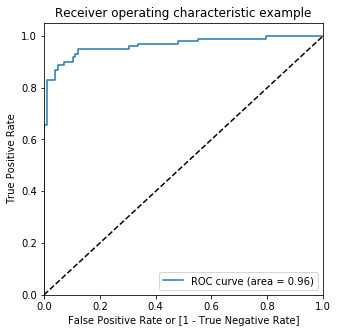

In [128]:
# Predicted probability
y_test_pred_proba_smote = logreg_smote_model.predict_proba(x_test)[:,1]
# Plot the ROC curve
draw_roc(y_test, y_test_pred_proba_smote)